# Sensitivities

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    grid_search_method,
    sweep_2d,
    contour_plot,
    evaluate
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

In [4]:
optimals = np.load("optimals_iteration3.npy")
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.969615650969529
Optimal delta_v: 3.0248441828254844
Optimal delta_v_angle: 0.074609375
Optimal tof: 0.7299271700356719


In [5]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: -4.48354203363803e-07
Objective value: 3.3171211191891916
Constraint Value in km: -0.17234735577304588
Objective Value in km/s: 3.3984880010688


In [6]:
theta_delta = 0.002

delta_v_delta = 0.002

delta_v_angle_delta = 0.001

tof_delta = 0.001

In [7]:
def run_sensitivity(param1, delta1, param2, delta2, grid_size=201):
    """
    Load or compute a 2D sensitivity sweep, find the minimum, and plot.

    Parameters
    ----------
    param1, param2 : str   Variable names ('theta', 'delta_v', 'delta_v_angle', 'tof')
    delta1, delta2 : float Perturbation half-ranges for each variable
    grid_size      : int   Grid resolution (default 201)

    Returns
    -------
    pd.DataFrame  The full sweep results
    """
    cache_path = Path(f"{param1}_{param2}_sweep.npy")

    if cache_path.exists():
        print(f"Loading cached {param1} vs {param2} sweep...")
        df = pd.DataFrame(
            np.load(cache_path),
            columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
        )
    else:
        print(f"Computing {param1} vs {param2} sweep...")
        df = sweep_2d(em, param1, delta1, param2, delta2, grid_size, optimals, leo_alt_m, lmo_alt_m)
        np.save(cache_path, df.values)

    min_row = df.loc[df['total_delta_v'].idxmin()]
    print(f"  min Δv = {min_row['total_delta_v']:.6f},  dist to LMO = {min_row['distance_to_lmo']:.6e}")

    contour_plot(df, param1, param2, grid_size, optimals)
    return df

## Theta v Delta_v

In [ ]:
theta_delta_v_sweep = run_sensitivity('theta', theta_delta, 'delta_v', delta_v_delta)

Computing theta vs delta_v sweep...
Performing grid search with 201 x 201 x 1 x 1 = 40401 grid points...
Iteration: 1478/40401
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.55 km, Total Delta_v=4.22 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.97 rad, Delta_v_angle=0.07 rad, TOF=0.73 s, Distance to LMO=0.55 km
Iteration: 2485/40401
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=-0.02 km, Total Delta_v=4.16 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.97 rad, Delta_v_angle=0.07 rad, TOF=0.73 s, Distance to LMO=-0.02 km
Iteration: 2626/40401
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.64 km, Total Delta_v=4.61 km/s
Iteration: 3492/40401
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.25 km, T

## Theta v Alpha

Loading cached theta vs delta_v_angle sweep...
  min Δv = 3.312479,  dist to LMO = -1.047101e-06


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto', vmin=3, vmax=3.6)


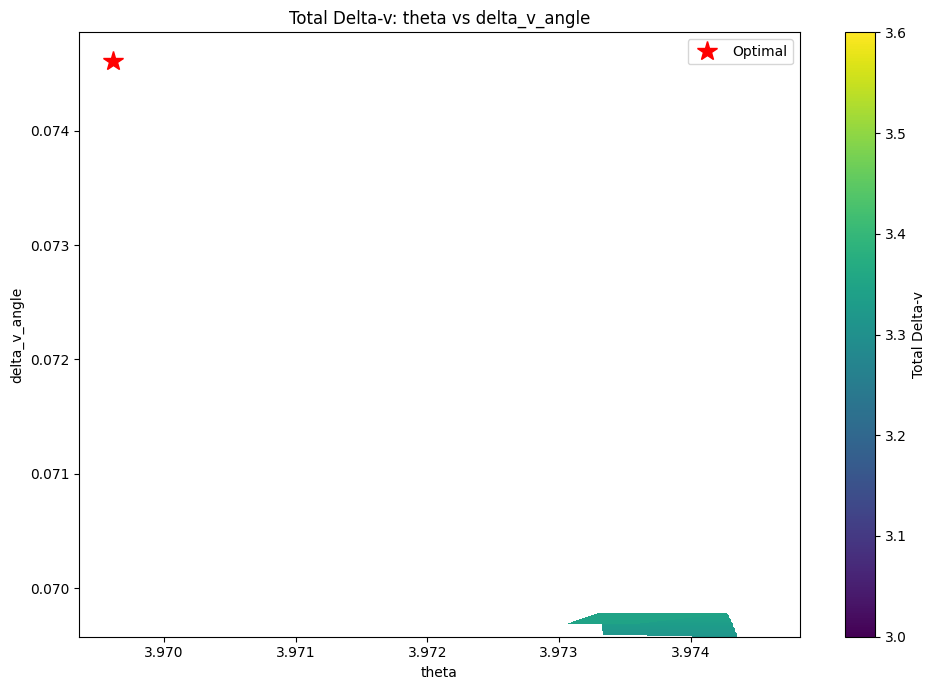

In [ ]:
theta_alpha_sweep = run_sensitivity('theta', theta_delta, 'delta_v_angle', delta_v_angle_delta)

## Theta v ToF

Loading cached theta vs tof sweep...
  min Δv = 3.316085,  dist to LMO = -2.906321e-06


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto', vmin=3, vmax=3.6)


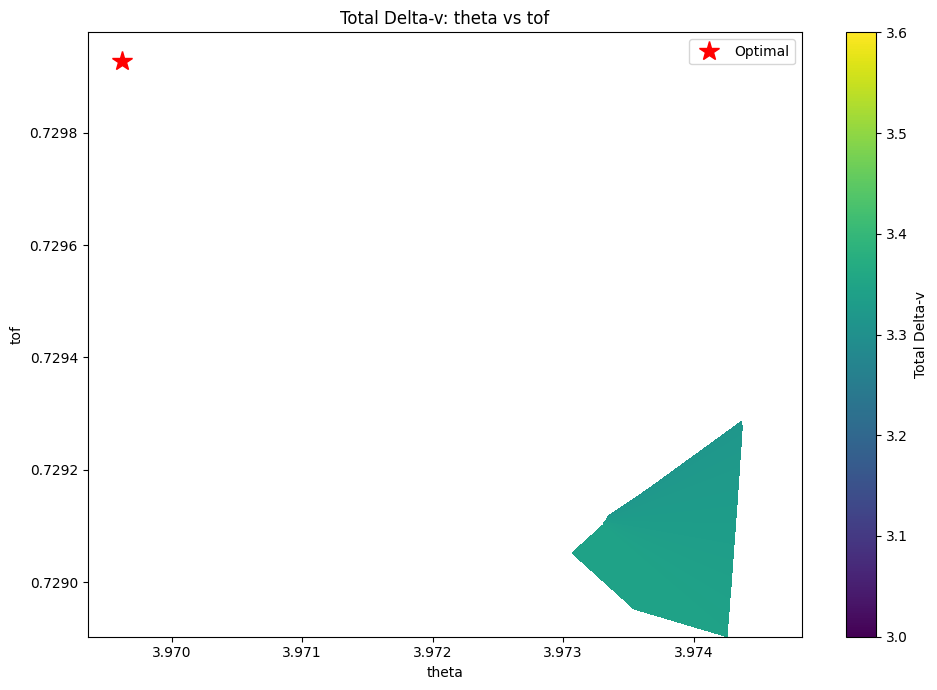

In [ ]:
theta_tof_sweep = run_sensitivity('theta', theta_delta, 'tof', tof_delta)

## Delta_v v Alpha

Loading cached delta_v vs delta_v_angle sweep...
  min Δv = 3.325731,  dist to LMO = -2.985915e-06


C:\Users\scoul\Documents\GitHub\TrajectoryOptimizer\cr3bp\plotting.py:122: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  contour = ax.pcolormesh(V1, V2, objective, cmap='viridis', shading='auto', vmin=3, vmax=3.6)


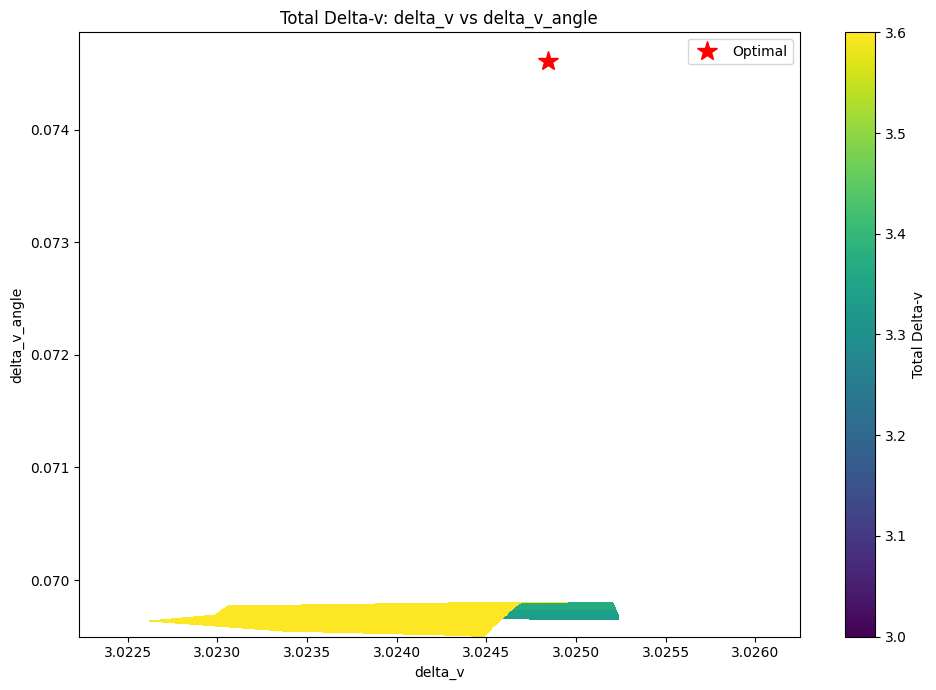

In [ ]:
delta_v_alpha_sweep = run_sensitivity('delta_v', delta_v_delta, 'delta_v_angle', delta_v_angle_delta)

## Delta_v v ToF

In [ ]:
delta_v_tof_sweep = run_sensitivity('delta_v', delta_v_delta, 'tof', tof_delta)

Computing delta_v vs tof sweep...
Performing grid search with 1 x 201 x 1 x 201 = 40401 grid points...
Error evaluating grid point: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s. Skipping.


## Alpha v ToF

In [ ]:
alpha_tof_sweep = run_sensitivity('delta_v_angle', delta_v_angle_delta, 'tof', tof_delta)